# Energy and RMSE

In [15]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy

from mirdotcom import mirdotcom

mirdotcom.init()

Time for the mathmatics!

**Energy** of a signal corresponds to the toal magnitude of the signal. For the audio signals, it roughly talks how LOUD the signal is. 

The energy is

 $$\sum_{n}|x(n)|^2$$
And as a following, root-mean-square energy (RMSE) in a signal is defined as 
$$\sqrt{\frac{1}{N}\sum_{n}|x(n)|^2}$$

Going deeper than the mirdotcom, 
$$E_s = \int_{-\infty}^{\infty}|x(t)|^2dt$$
in the continuous time. 
Above is more close to the discrete time frame which is
$$E_s= \sum_{n = -\infty}^{\infty}|x(n)|^2$$

In [ ]:
fp = mirdotcom.get_audio("simple_loop.wav")
x, sr = librosa.load(fp)

In [18]:
librosa.get_duration(y = x, sr = sr)
ipd.Audio(x,rate=sr)

Text(22.472222222222214, 0.5, 'Amplitude')

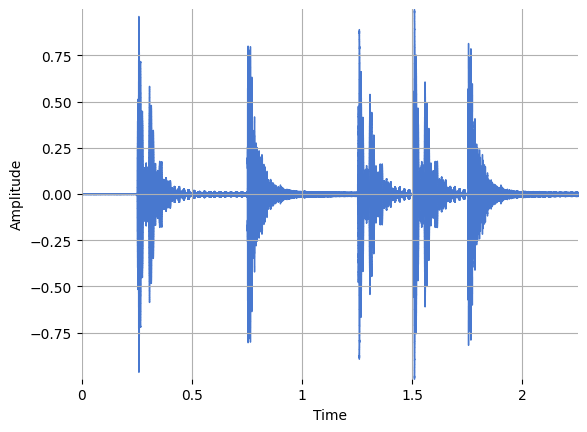

In [19]:
librosa.display.waveshow(x,sr=sr)
plt.ylabel("Amplitude")

In [22]:
hop_length = 256 # again, what is the hop_length; hopping?
frame_length = 512 # window to compute the energy
energy = []
for i in range(0, len(x), hop_length):
    frame = x[i : i + frame_length]
    energy.append(numpy.sum(numpy.abs(frame) ** 2))
energy = numpy.array(energy)
energy.shape

(194,)

In [26]:
rmse = librosa.feature.rms(
    y = x, frame_length=frame_length, hop_length=hop_length, center = True
)
rmse.shape
rmse=rmse[0] # changing removing away the another secondary dimension

Text(22.472222222222214, 0.5, 'Amplitude')

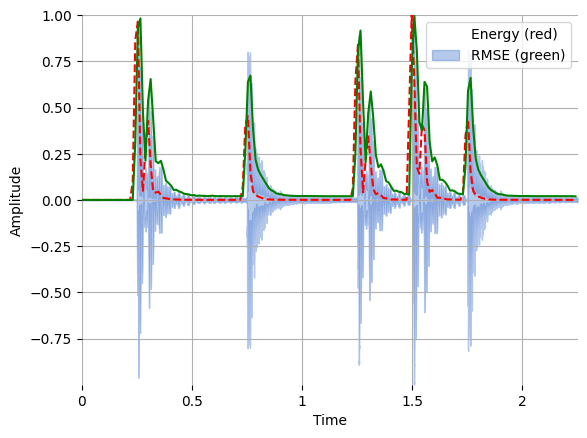

In [27]:
frames = range(len(energy))
t = librosa.frames_to_time(frames, sr=sr, hop_length=hop_length)
librosa.display.waveshow(x, sr=sr, alpha=0.4)
plt.plot(t, energy / energy.max(), "r--")  # normalized for visualization
plt.plot(t[: len(rmse)], rmse / rmse.max(), color="g")  # normalized for visualization
plt.legend(("Energy (red)", "RMSE (green)"))
plt.ylabel("Amplitude")

## Just a simple basic practice

In [ ]:
# removing the quite sound at the front of the audio signal. 
def strip(x, frame_length, hop_length):
    rmse = librosa.feature.rms(
        y = x, frame_length=frame_length, hop_length=hop_length, center = True
    )

    #identify the first frame where the RMSE exceeds a threshold
    thresh = 0.01
    frame_index = 0
    while rmse[0][frame_index] < thresh:
        frame_index+=1 # loop around and seek for the start of the energy

    start_sample_index = librosa.frames_to_samples(frame_index, hop_length=hop_length)

    return x[start_sample_index:]

y = strip(x, frame_length, hop_length)
ipd.Audio(y,rate = sr)

Text(22.472222222222214, 0.5, 'Amplitude')

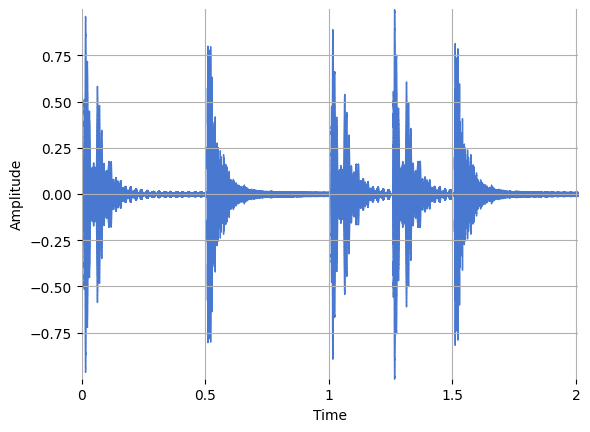

In [32]:
librosa.display.waveshow(y, sr = sr)
plt.ylabel("Amplitude")